# Preparación y Análisis Exploratorio de Datos
En este notebook, realizaremos la preparación y el análisis exploratorio de datos en el conjunto de datos `styles.csv`.

# Desarrollo de Modelo Supervisado
En esta sección, desarrollaremos un modelo de aprendizaje supervisado utilizando el conjunto de datos `styles.csv`. Los pasos incluyen:
1. Preprocesamiento de datos.
2. División del conjunto de datos en conjuntos de entrenamiento y prueba.
3. Entrenamiento de un modelo de aprendizaje supervisado.
4. Evaluación del rendimiento del modelo.

Filas y columnas: (44424, 10)
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  

Valores nulos por columna:
id                      0
gender                  0
masterCategory     

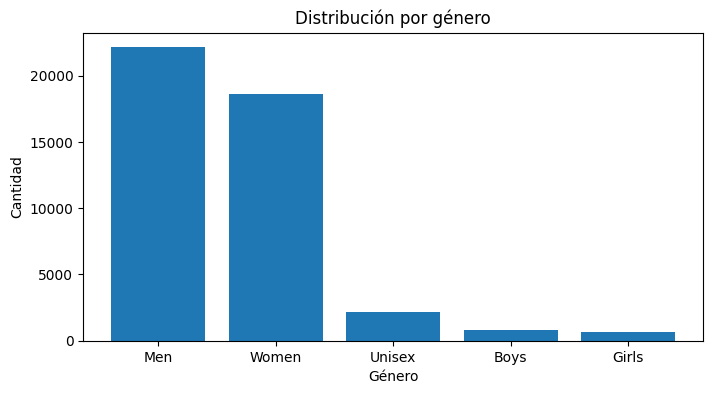

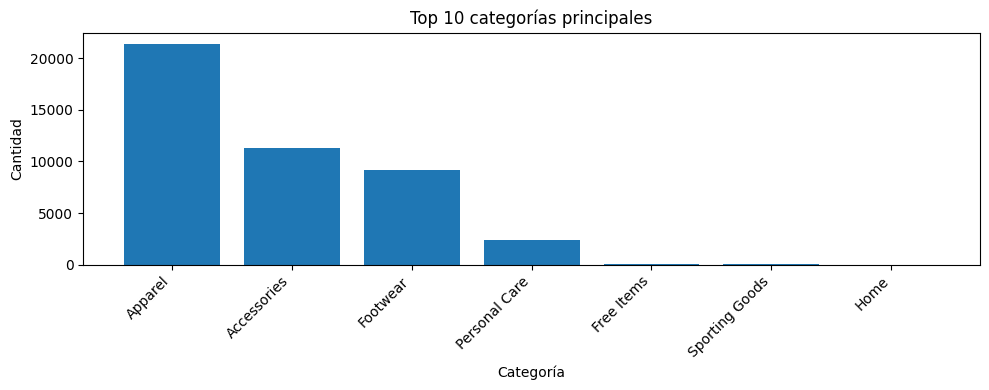

Precisión modelo base: 0.7837


In [5]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1) Cargar datos de forma robusta
# on_bad_lines='skip' evita que el proceso se detenga por filas corruptas
df = pd.read_csv('styles.csv', engine='python', on_bad_lines='skip')
print('Filas y columnas:', df.shape)
print(df.head())

# 2) Análisis exploratorio simple
print('\nValores nulos por columna:')
print(df.isnull().sum())

# Gráfico simple por género
conteo_genero = df['gender'].value_counts()
plt.figure(figsize=(8, 4))
plt.bar(conteo_genero.index.astype(str), conteo_genero.values)
plt.title('Distribución por género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.show()

# Gráfico simple por categoría principal
conteo_categoria = df['masterCategory'].value_counts().head(10)
plt.figure(figsize=(10, 4))
plt.bar(conteo_categoria.index.astype(str), conteo_categoria.values)
plt.title('Top 10 categorías principales')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

# 3) Modelo supervisado (simple)
objetivo = 'articleType'
columnas_modelo = ['gender', 'masterCategory', 'subCategory', 'baseColour', 'season', 'year', 'usage']
datos_sup = df[columnas_modelo + [objetivo]].dropna().copy()

freq = datos_sup[objetivo].value_counts()
clases_validas = freq[freq >= 20].index
datos_sup = datos_sup[datos_sup[objetivo].isin(clases_validas)].copy()

X = pd.get_dummies(datos_sup[columnas_modelo], drop_first=True)
y = datos_sup[objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo_base = RandomForestClassifier(n_estimators=150, random_state=42)
modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f'Precisión modelo base: {acc_base:.4f}')

# Desarrollo de Modelo No Supervisado
En esta sección, implementaremos un método de aprendizaje no supervisado utilizando el conjunto de datos `styles.csv`. Los pasos incluyen:
1. Preprocesamiento de datos para aprendizaje no supervisado.
2. Aplicación de un algoritmo de clustering (por ejemplo, K-Means).
3. Visualización de los clusters.

Puntaje de silueta: 0.4941


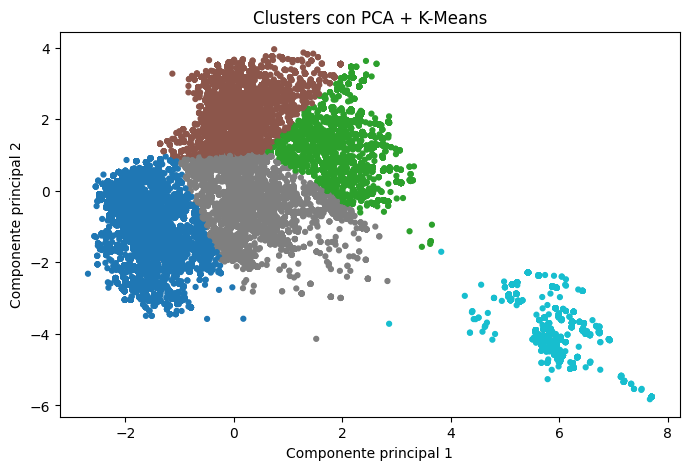

In [6]:
# Modelo no supervisado (simple): PCA + K-Means
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cargar datos de forma robusta (celda independiente)
df_ns = pd.read_csv('styles.csv', engine='python', on_bad_lines='skip')

# Preprocesamiento para clustering
columnas_cluster = ['gender', 'masterCategory', 'subCategory', 'baseColour', 'season', 'usage', 'year']
datos_ns = df_ns[columnas_cluster].dropna().copy()

X_ns = pd.get_dummies(datos_ns, drop_first=True)
X_ns = StandardScaler().fit_transform(X_ns)

# Reducción de dimensionalidad para visualizar
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_ns)

# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Métrica de calidad
silueta = silhouette_score(X_pca, clusters)
print(f'Puntaje de silueta: {silueta:.4f}')

# Visualización de clusters
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=12)
plt.title('Clusters con PCA + K-Means')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.show()

# Optimización de Hiperparámetros
En esta sección, realizaremos la optimización de hiperparámetros para el modelo de aprendizaje supervisado utilizando Grid Search o Randomized Search.

In [7]:
# Optimización de hiperparámetros (simple)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)
modelo_opt = grid.best_estimator_
y_pred_opt = modelo_opt.predict(X_test)
acc_opt = accuracy_score(y_test, y_pred_opt)

print('Mejores hiperparámetros:')
print(grid.best_params_)
print(f'Precisión optimizada: {acc_opt:.4f}')

Mejores hiperparámetros:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Precisión optimizada: 0.7822


# Evaluación y Comparación de Modelos
En esta sección, evaluaremos y compararemos el rendimiento de los modelos supervisados y no supervisados desarrollados anteriormente. Esto incluirá métricas clave y visualizaciones para analizar los resultados.

Comparación de resultados:
- Modelo base: 0.7837
- Modelo optimizado: 0.7822

Reporte de clasificación (modelo optimizado):
                       precision    recall  f1-score   support

   Accessory Gift Set       1.00      0.95      0.97        19
            Backpacks       0.74      0.95      0.83       145
               Bangle       0.57      0.24      0.33        17
                Belts       0.99      1.00      1.00       163
               Boxers       1.00      0.30      0.46        10
                  Bra       0.61      0.88      0.72        95
             Bracelet       0.33      0.31      0.32        13
               Briefs       0.57      0.73      0.64       169
            Camisoles       0.00      0.00      0.00         8
               Capris       0.40      0.23      0.29        35
                 Caps       1.00      1.00      1.00        57
         Casual Shoes       0.93      0.94      0.94       569
             Churidar       1.00      0.17      0.29    

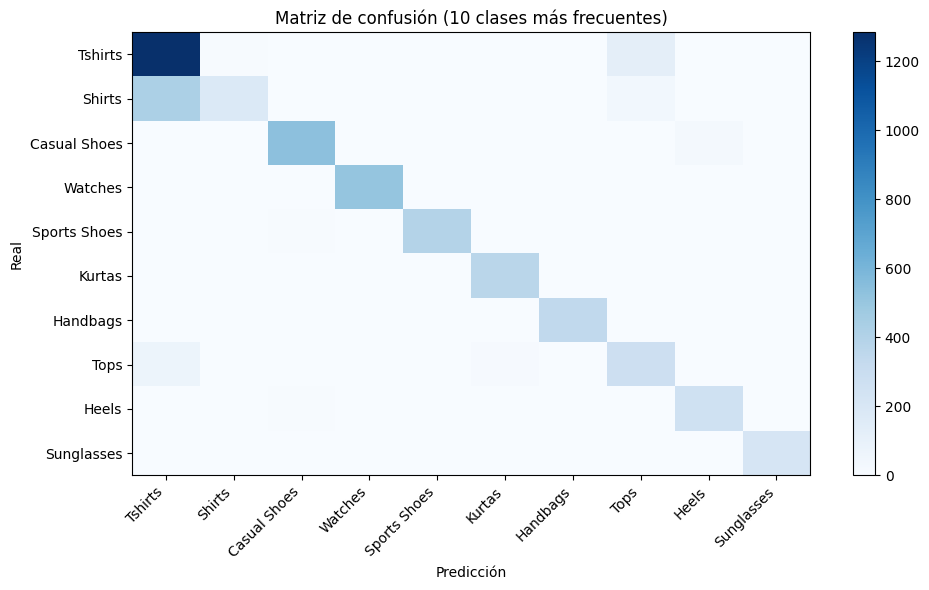


Conclusión breve:
Se construyó un flujo simple con EDA, clasificación, clustering, optimización y evaluación.


In [8]:
# Evaluación y comparación de modelos
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print('Comparación de resultados:')
print(f'- Modelo base: {acc_base:.4f}')
print(f'- Modelo optimizado: {acc_opt:.4f}')

print('\nReporte de clasificación (modelo optimizado):')
print(classification_report(y_test, y_pred_opt, zero_division=0))

# Matriz de confusión para clases más frecuentes
top_clases = y_test.value_counts().head(10).index
mascara = y_test.isin(top_clases)
cm = confusion_matrix(y_test[mascara], pd.Series(y_pred_opt, index=y_test.index)[mascara], labels=top_clases)

plt.figure(figsize=(10, 6))
plt.imshow(cm, cmap='Blues', aspect='auto')
plt.title('Matriz de confusión (10 clases más frecuentes)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.colorbar()

pos = np.arange(len(top_clases))
plt.xticks(pos, top_clases, rotation=45, ha='right')
plt.yticks(pos, top_clases)
plt.tight_layout()
plt.show()

print('\nConclusión breve:')
print('Se construyó un flujo simple con EDA, clasificación, clustering, optimización y evaluación.')